In [146]:
import numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

In [147]:
df = pd.read_csv("mall customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [148]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [149]:
df[df.duplicated()]

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)


In [150]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [151]:
df.shape
df = df.drop(["CustomerID"], axis = 1)

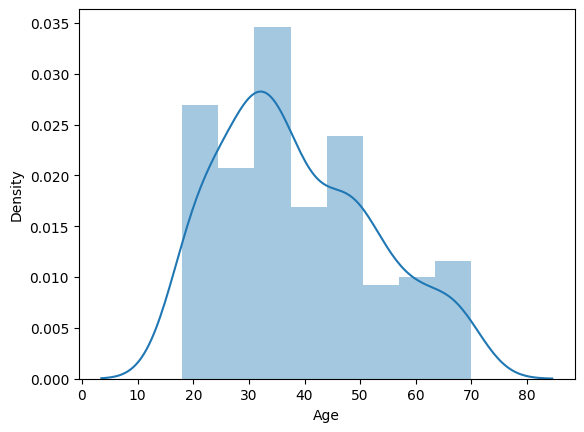

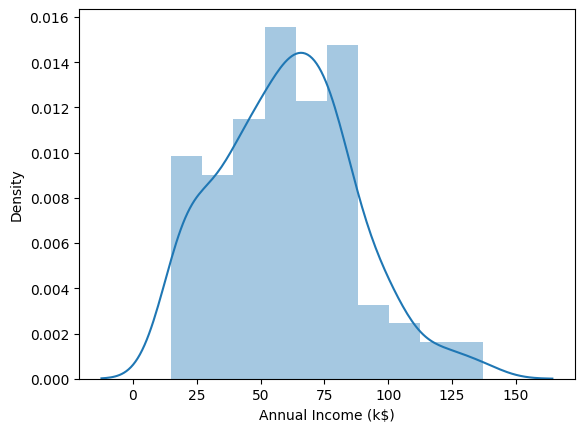

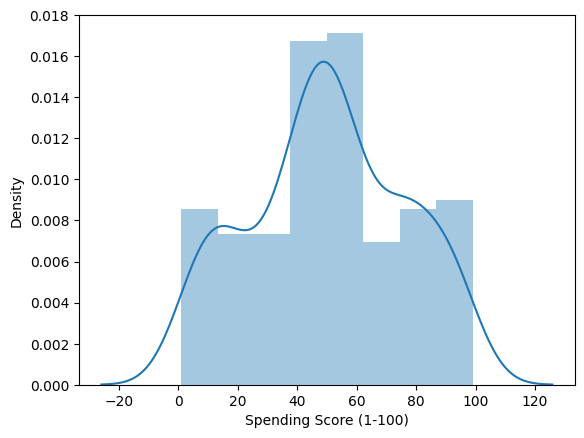

In [152]:
num_columns = ['Age', 'Annual Income (k$)','Spending Score (1-100)']
for col in num_columns:
  plt.figure();
  sns.distplot(df[col]);
  plt.show()

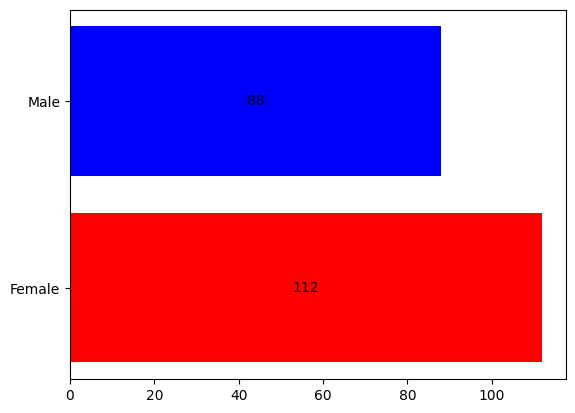

In [153]:
from seaborn.widgets import color_palette
plt.figure()
barh = plt.barh(df['Gender'].value_counts().index, df['Gender'].value_counts().sort_values(ascending=False), color = ["red", "blue"])
plt.bar_label(barh, label_type="center")
plt.show()

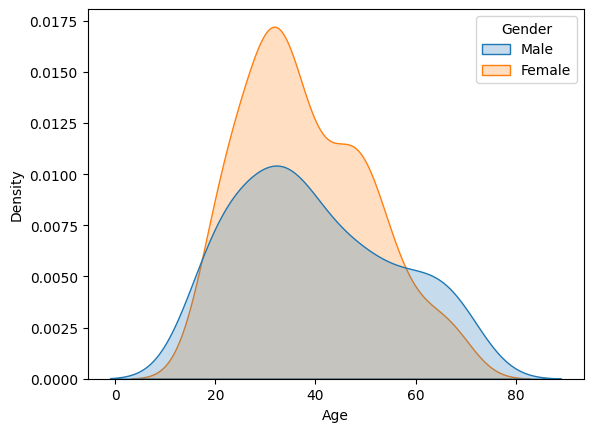

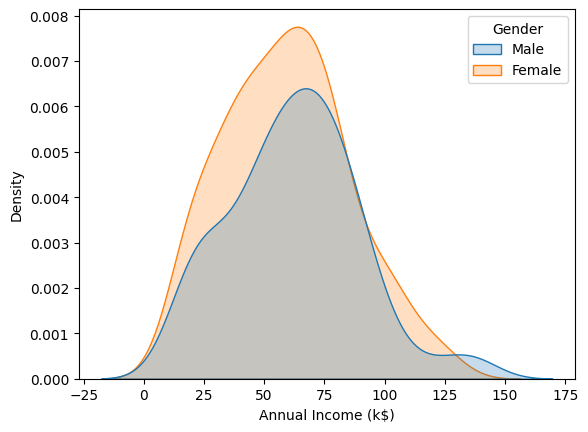

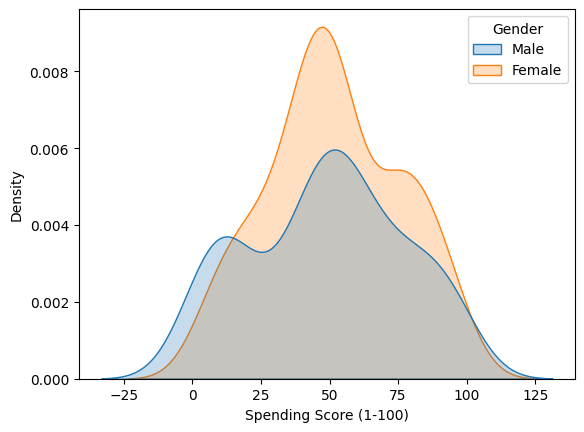

In [154]:
for col in num_columns:
  plt.figure();
  sns.kdeplot(data=df, x = col, shade = True, hue = 'Gender')
  plt.show()

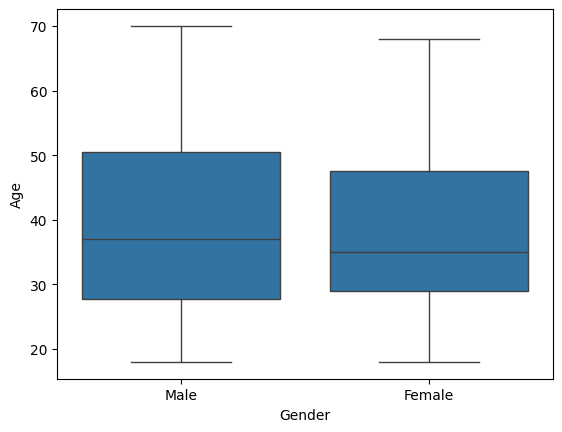

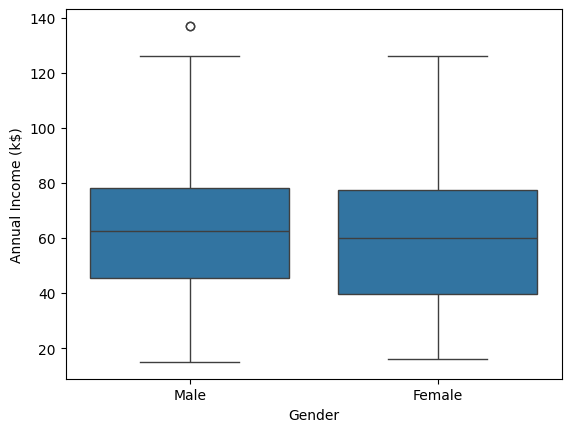

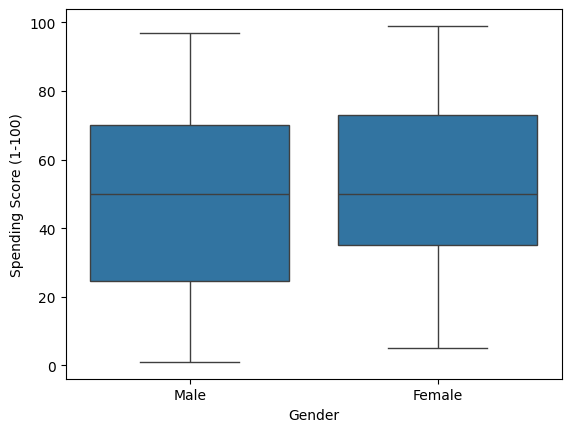

In [155]:
for col in num_columns:
  plt.figure()
  sns.boxplot(data = df, x = 'Gender', y = col)
  plt.show()

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

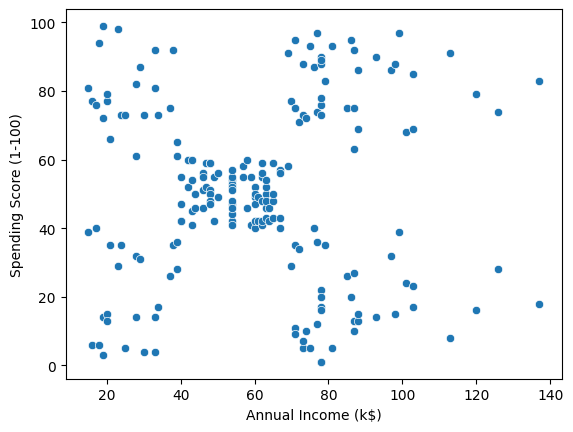

In [156]:
sns.scatterplot(data = df, x = "Annual Income (k$)" , y = "Spending Score (1-100)")

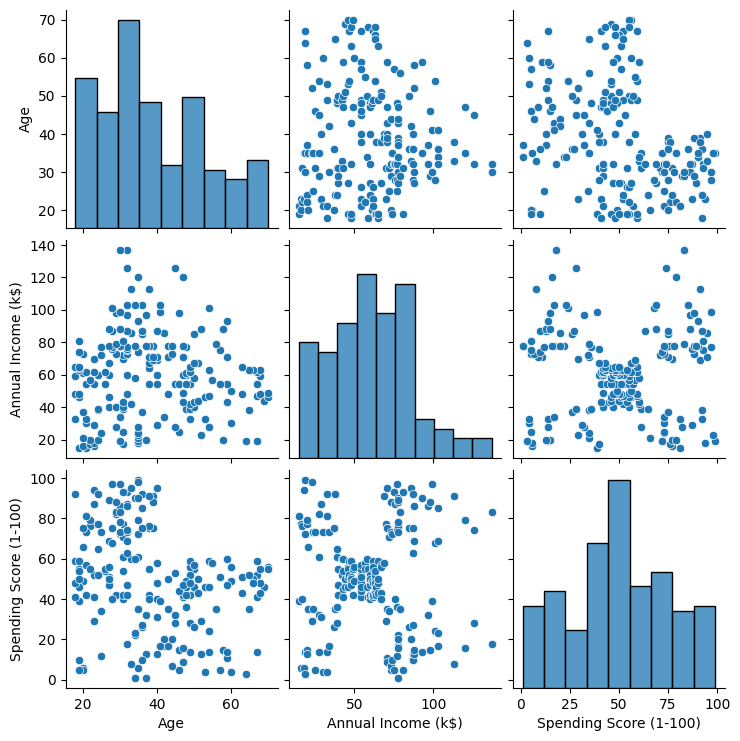

In [157]:
sns.pairplot(df)

In [158]:
df.groupby(["Gender"])[num_columns].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Gender,,,
Female,38.098214,59.250000,51.526786
Male,39.806818,62.227273,48.511364


<Axes: >

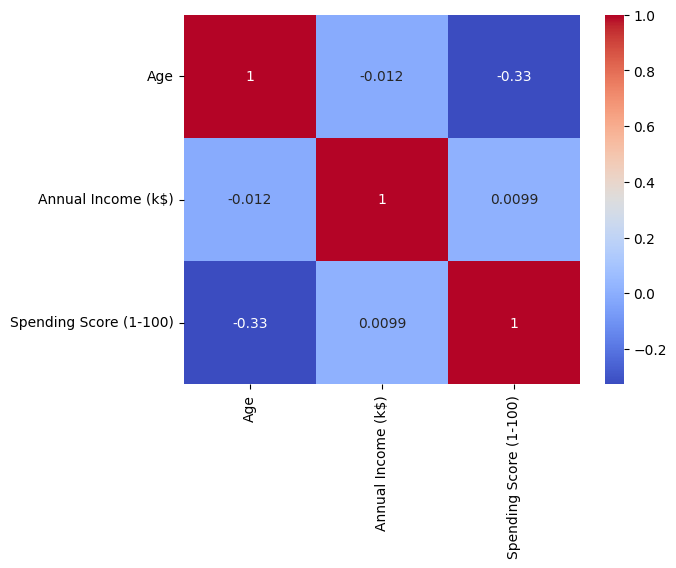

In [159]:
sns.heatmap(df.corr(numeric_only=True),annot=True, cmap = "coolwarm")

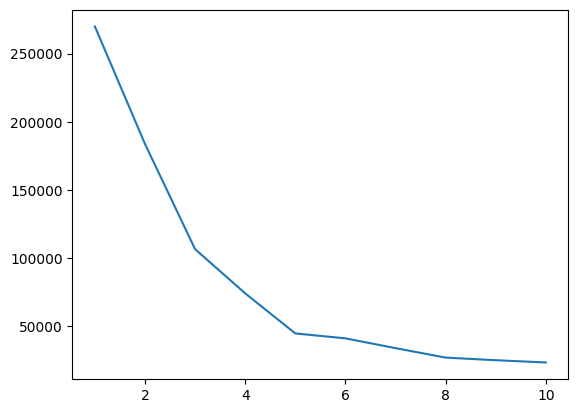

In [160]:
inertia_scores = []
for i in range(1,11):
  point = KMeans(n_clusters=i, random_state= 42, init="k-means++")
  point.fit(df[["Annual Income (k$)","Spending Score (1-100)"]])
  inertia_scores.append(point.inertia_)
plt.plot(range(1,11), inertia_scores)
plt.show()

In [161]:
clustering = KMeans(n_clusters=5, random_state= 42, init="k-means++")
df["Cluster"] = clustering.fit_predict(df[["Annual Income (k$)","Spending Score (1-100)"]])

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

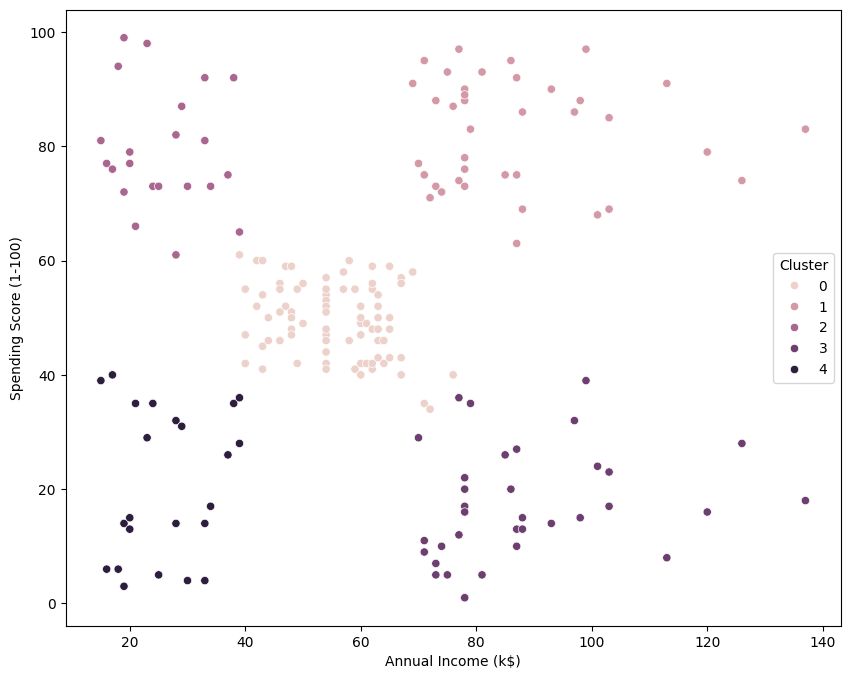

In [162]:
plt.figure(figsize=(10,8))
sns.scatterplot(data= df, x = "Annual Income (k$)", y = "Spending Score (1-100)", hue = "Cluster")
plt.show()

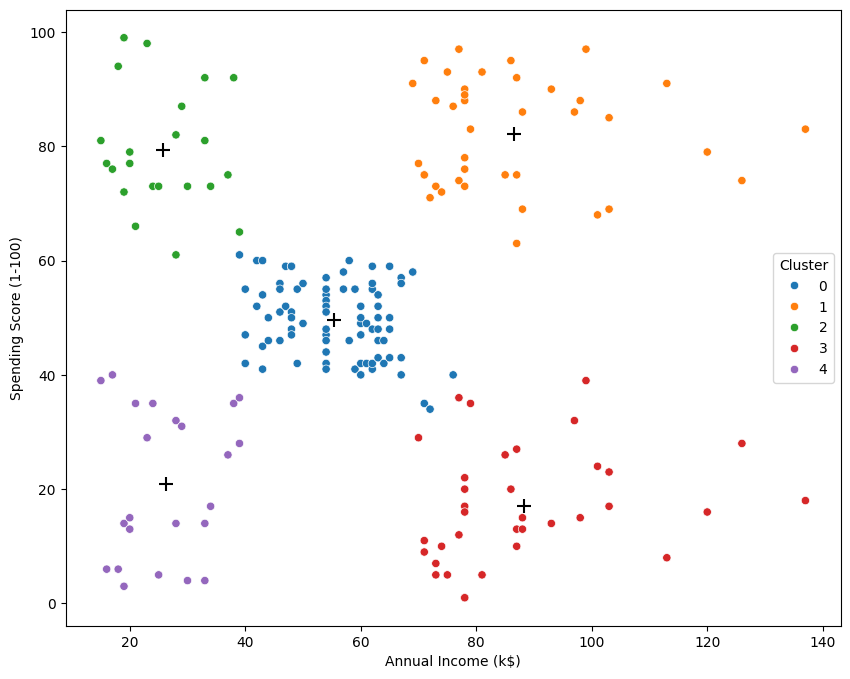

In [163]:
centers = pd.DataFrame(clustering.cluster_centers_)
centers.columns = ["x","y"]
plt.figure(figsize = (10,8))
sns.scatterplot(data = df, x = "Annual Income (k$)", y = "Spending Score (1-100)", hue = "Cluster", palette = "tab10")
plt.scatter(data= centers, x = "x", y = "y", s=100, color = "black", marker = "+")
plt.show()

In [164]:
pd.crosstab(df['Cluster'], df['Gender'])

Gender,Female,Male
Cluster,,
0,48,33
1,21,18
2,13,9
3,16,19
4,14,9


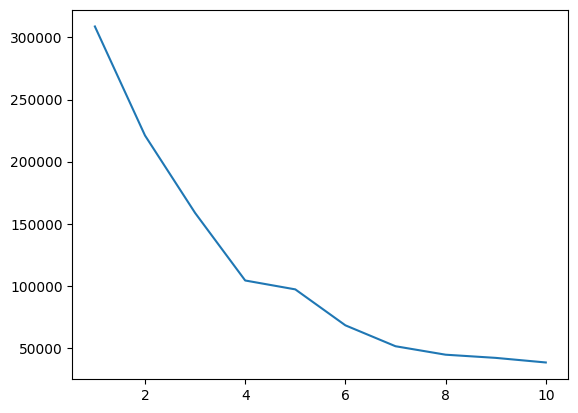

In [175]:
inertia_scores2 = []
for i in range(1,11):
  point = KMeans(n_clusters=i,random_state=42, init="k-means++")
  point.fit(df[num_columns])
  inertia_scores2.append(point.inertia_)

plt.figure()
plt.plot(range(1,11),inertia_scores2)
plt.show()

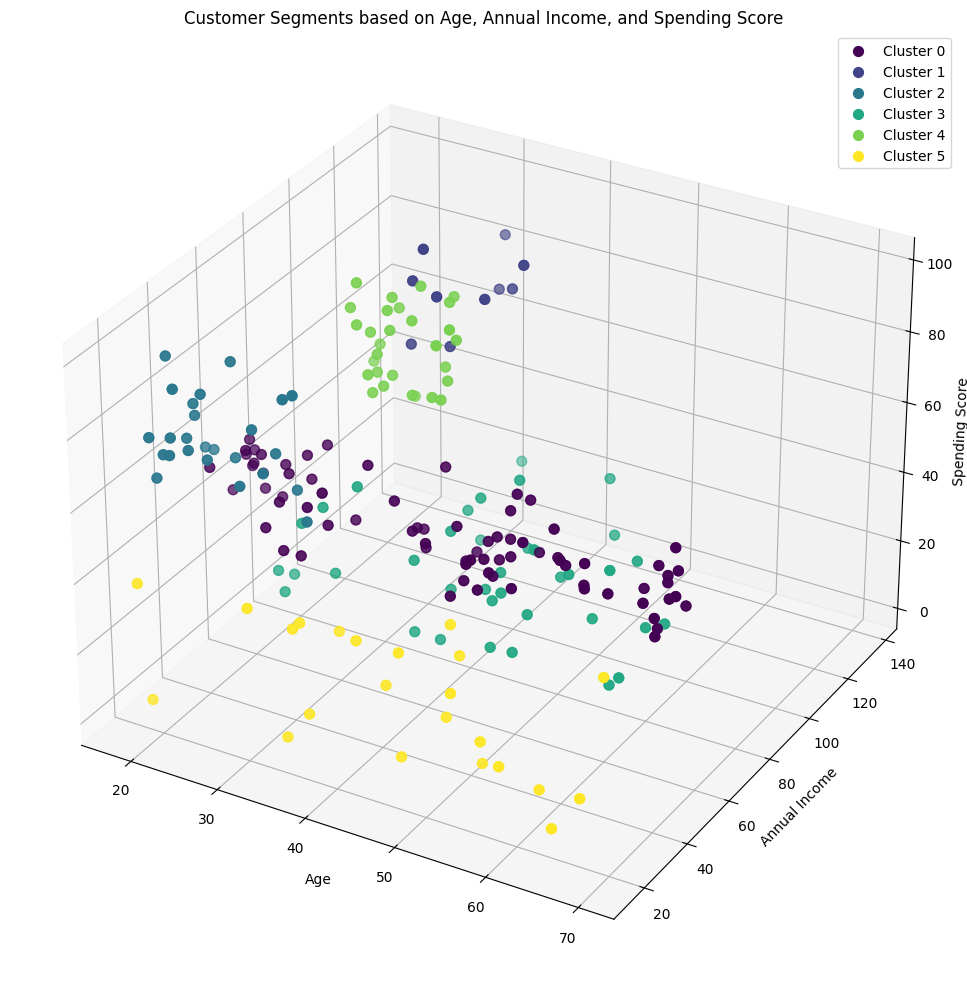

In [183]:
clustering2 = KMeans(n_clusters = 6, random_state = 42, init = "k-means++")
df["MultiCluster"] = clustering2.fit_predict(df[num_columns])

figure = plt.figure(figsize = (10,10))
ax = figure.add_subplot(111, projection = "3d")
ax.scatter(df["Age"], df["Annual Income (k$)"],df["Spending Score (1-100)"], c = df["MultiCluster"], s = 50, cmap = "viridis")
clusters = sorted(df["MultiCluster"].unique())
colors = plt.cm.viridis([i / (len(clusters) - 1) for i in range(len(clusters))])

for cluster_id, color in zip(clusters, colors):
    subset = df[df["MultiCluster"] == cluster_id]
    ax.scatter(subset["Age"], subset["Annual Income (k$)"], subset["Spending Score (1-100)"],
               s=50, color=color, label=f"Cluster {cluster_id}")
ax.set_xlabel("Age")
ax.set_ylabel("Annual Income")
ax.set_zlabel("Spending Score")
plt.title('Customer Segments based on Age, Annual Income, and Spending Score')
plt.legend()
plt.tight_layout()
plt.show()